In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# Load the input image
image = cv2.imread('input.png')
if image is None:
    print("Error: Image not found.")
else:
    # Convert BGR to RGB for Jupyter display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [19]:
# Get image dimensions
h, w = image.shape[:2]

In [20]:
src_points = np.float32([
    [420, 170],
    [650, 150],
    [680, 420],
    [400, 440]
])

In [21]:
# Destination points (A4 shape)
width = 300
height = 420

dst_points = np.float32([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
])

In [22]:
# Estimate the perspective transformation matrix
matrix = cv2.getPerspectiveTransform(src_points, dst_points)
print("Estimated Perspective Transformation Matrix:")
print(matrix)


Estimated Perspective Transformation Matrix:
[[ 1.64418852e+00  1.21791742e-01 -7.11263775e+02]
 [ 2.04501350e-01  2.35176552e+00 -4.85690705e+02]
 [ 1.58187481e-04  9.97354798e-04  1.00000000e+00]]


In [ ]:
# Apply perspective warping
warped_image = cv2.warpPerspective(image, matrix, (width, height))
warped_rgb = cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB)

(np.float64(-0.5), np.float64(1023.5), np.float64(1535.5), np.float64(-0.5))

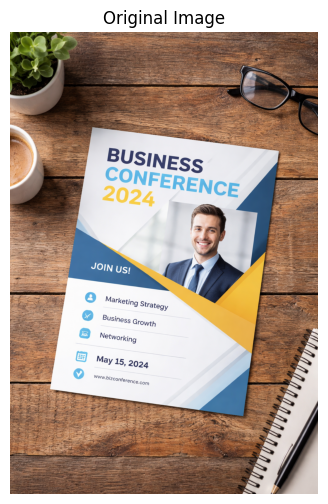

In [24]:
# Display original and warped image in Jupyter
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(1535.5), np.float64(-0.5))

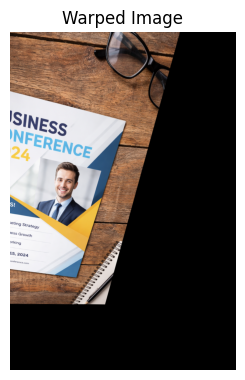

In [25]:
plt.subplot(1, 2, 2)
plt.imshow(warped_rgb)
plt.title("Warped Image")
plt.axis("off")

In [ ]:
# Save the output image
cv2.imwrite("warped_output.jpg", warped_image)

cv2.waitKey(0)
cv2.destroyAllWindows()